# MAXWELL TURNER - ASSIGNMENT 2.2 BANKNOTE EDA - WEEK 2

## Load and Inspect the Data

In [89]:
import pandas as pd
import matplotlib.pyplot as plt

In [90]:
df = pd.read_csv("../data/banknote-auth.csv")
print("shape:", df.shape)
df.sample(10)

shape: (1372, 5)


,variance,skewness,kurtosis,entropy,label
363,2.80500,0.57732,1.342400,1.213300,0
241,-1.39310,1.56640,7.538200,0.784030,0
404,0.37980,0.70980,0.757200,-0.444400,0
1251,-0.77688,0.13036,-0.031137,-0.353890,1
157,3.94790,-3.77230,2.883000,0.019813,0
655,2.65620,10.70440,-3.308500,-4.076700,0
229,5.49440,1.54780,0.041694,1.928400,0
782,-0.34810,-0.38696,-0.478410,0.626270,1
23,0.93584,8.88550,-1.683100,-1.659900,0
1298,-0.96070,2.69630,-3.122600,-1.312100,1


In [91]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1372 entries, 0 to 1371
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   variance  1372 non-null   float64
 1   skewness  1372 non-null   float64
 2   kurtosis  1372 non-null   float64
 3   entropy   1372 non-null   float64
 4   label     1372 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 53.7 KB


Every column shows 1372 non null so there's no missing data to clean up. The four features are float64 and the label is already int64, so I don't have to convert text to numbers like I did with iris in 1.2.

## Class Balance

In [92]:
class_counts = df["label"].value_counts() #counting how many of each so I know if it's lopsided
print(class_counts)
print()
print(df["label"].value_counts(normalize=True).round(3))

label
0    762
1    610
Name: count, dtype: int64

label
0    0.555
1    0.445
Name: proportion, dtype: float64


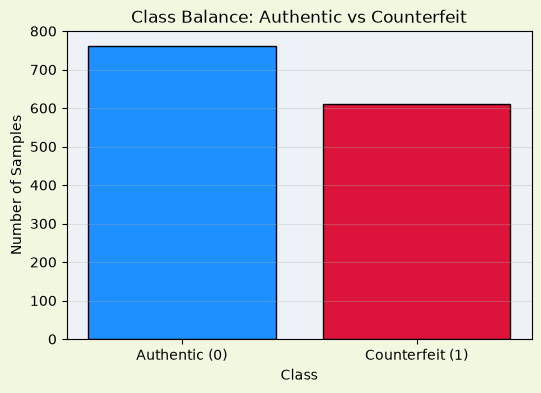

In [93]:
#my bar chart so the split is easy to see
plt.figure(figsize=(6, 4))
plt.gcf().set_facecolor("#f2f7e0")
plt.gca().set_facecolor("#eef2f7")
plt.bar(["Authentic (0)", "Counterfeit (1)"], class_counts.values,
        color=["dodgerblue", "crimson"], edgecolor="black")
plt.xlabel("Class")
plt.ylabel("Number of Samples")
plt.title("Class Balance: Authentic vs Counterfeit")
plt.grid(axis="y", alpha=0.3)
plt.show()

762 authentic and 610 counterfeit so about 55/45. Close but not even. That matters because it means my baseline isn't 50% a model that just guessed authentic every time would already score 55.5%.

## Visual Exploration
Splitting the dataframe by class so each group gets its own color and label on the scatterplots.

In [94]:
authentic = df[df["label"] == 0]
counterfeit = df[df["label"] == 1]

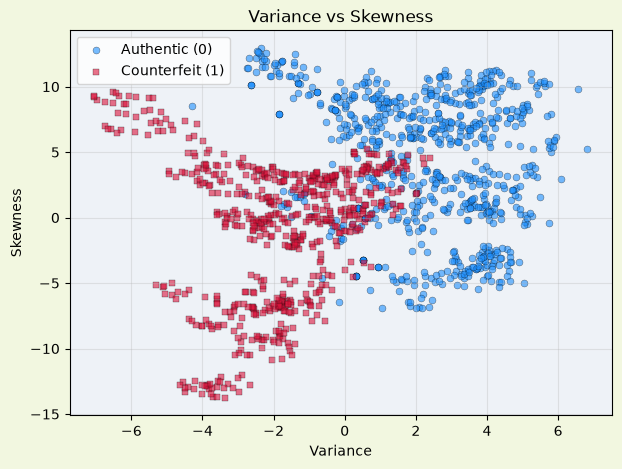

In [95]:
# best looking pair I found
plt.figure(figsize=(7, 5))
plt.gcf().set_facecolor("#f2f7e0")
plt.gca().set_facecolor("#eef2f7")
plt.scatter(authentic["variance"], authentic["skewness"], color="dodgerblue",
            label="Authentic (0)", s=25, alpha=0.6, edgecolor="black", linewidth=0.3)
plt.scatter(counterfeit["variance"], counterfeit["skewness"], color="crimson",
            label="Counterfeit (1)", s=25, alpha=0.6, edgecolor="black",
            linewidth=0.3, marker="s")
plt.xlabel("Variance")
plt.ylabel("Skewness")
plt.title("Variance vs Skewness")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

They overlap in the middle no clean gap like iris had. The two colors do end up mostly on different sides blue to the right and red to the left but there are blue points sitting inside the red area and red points inside the blue.

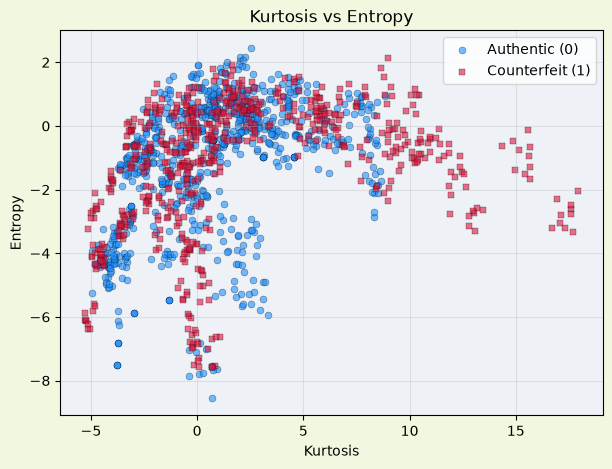

In [96]:
#other two features ... way worse
plt.figure(figsize=(7, 5))
plt.gcf().set_facecolor("#f2f7e0")
plt.gca().set_facecolor("#eef2f7")

plt.scatter(authentic["kurtosis"], authentic["entropy"], color="dodgerblue",
            label="Authentic (0)", s=25, alpha=0.6, edgecolor="black", linewidth=0.3)
plt.scatter(counterfeit["kurtosis"], counterfeit["entropy"], color="crimson",
            label="Counterfeit (1)", s=25, alpha=0.6, edgecolor="black",
            linewidth=0.3, marker="s")

plt.xlabel("Kurtosis")
plt.ylabel("Entropy")
plt.title("Kurtosis vs Entropy")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

This pair is way worse. The colors are completely mixed with no pattern at all, so kurtosis and entropy barely tell me anything about whether a note is fake.

## Correlation and Collinearity

In [97]:
#Correlation between the 4 features
feats = ["variance", "skewness", "kurtosis", "entropy"]
corr = df[feats].corr()
print(corr.round(3))

          variance  skewness  kurtosis  entropy
variance     1.000     0.264    -0.381    0.277
skewness     0.264     1.000    -0.787   -0.526
kurtosis    -0.381    -0.787     1.000    0.319
entropy      0.277    -0.526     0.319    1.000


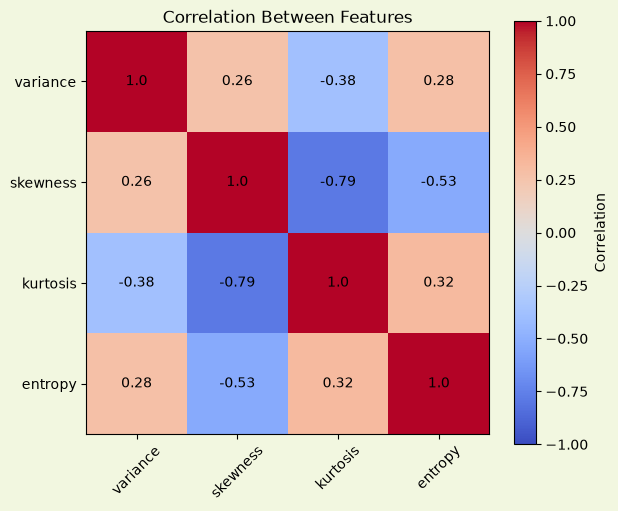

In [98]:
# heatmap
plt.figure(figsize=(6.5, 5.5))
plt.gcf().set_facecolor("#f2f7e0")

plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(label="Correlation")
plt.xticks(range(len(feats)), feats, rotation=45)
plt.yticks(range(len(feats)), feats)

# write the numbers into the sqs 
for i in range(len(feats)):
    for j in range(len(feats)):
        plt.text(j, i, round(corr.iloc[i, j], 2), ha="center", va="center")

plt.title("Correlation Between Features")
plt.show()


**What stands out to me:** skewness and kurtosis are at -0.79 which is pretty strong, they're basically telling me a lot of the same thing just flipped. That's collinearity. Skewness and entropy at -0.53 is the next biggest. Everything else is under 0.4 so the features are mostly independent.

## Reflection

**Q1 How balanced are the two classes?**

Pretty close but not even. 762 authentic and 610 counterfeit, so about 55/45. Not bad enough to be a real problem, but it does mean my baseline isn't 50%. A model that just guessed "authentic" every single time would score 55.5%, so that's the number I actually have to beat before the model has done anything.

**Q2 Which feature pair shows the best separation?**

Variance and skewness. The two groups end up mostly on different sides, blue to the right and red to the left. Kurtosis vs entropy was the total opposite, the colors were completely mixed with no pattern at all. That lines up with the correlation numbers since variance has the strongest relationship with the label and entropy has almost none.

**Q3 Does the data appear linearly separable?**

Not really, at least not with two features. On the variance vs skewness plot the groups overlap in the middle instead of leaving a gap, and there are blue points sitting inside the red area and the other way around. A straight line would get most of it but would definitely miss a chunk. This is way messier than the iris data in 1.2 where there was a clean empty gap. Using all four features at once might separate it better since a line in 4D has more room to work with, but I can't see that on a 2D plot.

**Q4 How do you think an MLP will do against a Perceptron on this data?**

Better. A perceptron only draws one straight line, and from these plots one line clearly isn't enough to split these two groups cleanly. An MLP has hidden layers so it can bend the boundary and curve around the overlapping parts. On the iris data it wouldn't have mattered because the perceptron already got 100%, but here there's actual overlap for the MLP to work with. I'd expect the perceptron to plateau somewhere decent but not great, and the MLP to beat it.